In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib, os, matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('../data/student-mat.csv', sep=';')
df['at_risk'] = (df['G3'] < 10).astype(int)

FEATURES = ['absences','studytime','failures','freetime',
            'goout','Dalc','Walc','health','famrel','traveltime']

X = df[FEATURES]
y = df['at_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 316, Test size: 79


In [7]:
# Handle imbalance — apply SMOTE on training data ONLY
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("After SMOTE:", X_train_res.shape)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_res)
X_test_s  = scaler.transform(X_test)

After SMOTE: (424, 10)


In [10]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train_s, y_train_res,
          eval_set=[(X_test_s, y_test)],
          verbose=False)
print("Training complete")

Training complete


              precision    recall  f1-score   support

 Not at risk       0.80      0.75      0.78        53
     At risk       0.55      0.62      0.58        26

    accuracy                           0.71        79
   macro avg       0.68      0.69      0.68        79
weighted avg       0.72      0.71      0.71        79



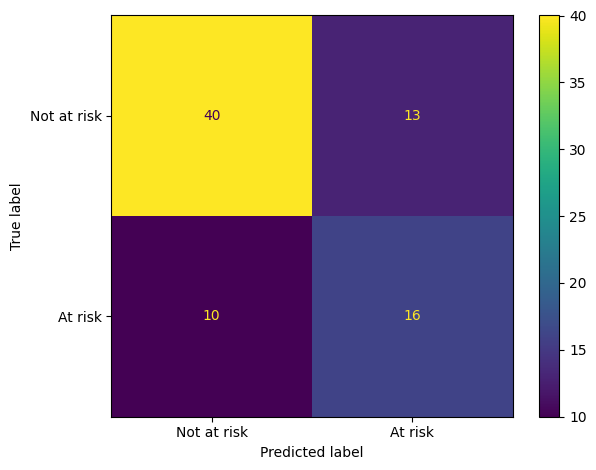

In [11]:
y_pred = model.predict(X_test_s)
print(classification_report(y_test, y_pred,
      target_names=['Not at risk','At risk']))

# Confusion matrix — shows in notebook inline
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not at risk','At risk'], ax=ax)
plt.tight_layout()
plt.show()

In [12]:
os.makedirs('../models', exist_ok=True)
joblib.dump(model,   '../models/xgb_model.pkl')
joblib.dump(scaler,  '../models/scaler.pkl')
joblib.dump(FEATURES,'../models/features.pkl')
print("Saved to ml/models/")
print("Files:", os.listdir('../models'))

Saved to ml/models/
Files: ['features.pkl', 'scaler.pkl', 'xgb_model.pkl']
